In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleaanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
import seaborn as sns

In [5]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

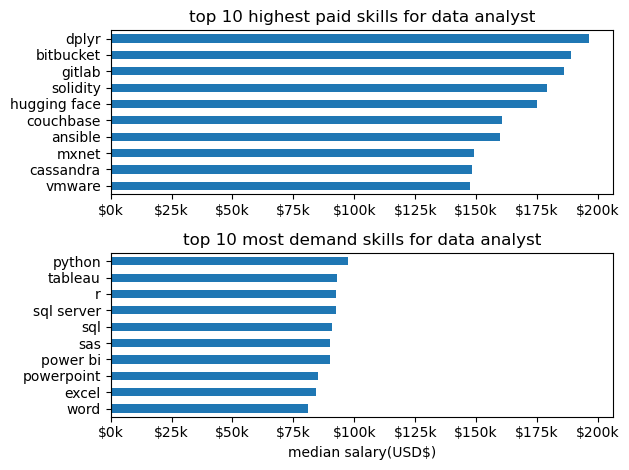

In [6]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DA_top_pay = df_DA_US_group.sort_values(by='median', ascending=False).head(10)

df_DA_skills = df_DA_US_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False).head(10)

fig, ax = plt.subplots(2, 1)

df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k' )
ax[0].set_title('top 10 highest paid skills for data analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')

df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k' )
ax[1].set_title('top 10 most demand skills for data analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('median salary(USD$)')
ax[1].set_xlim(ax[0].get_xlim())

fig.tight_layout()


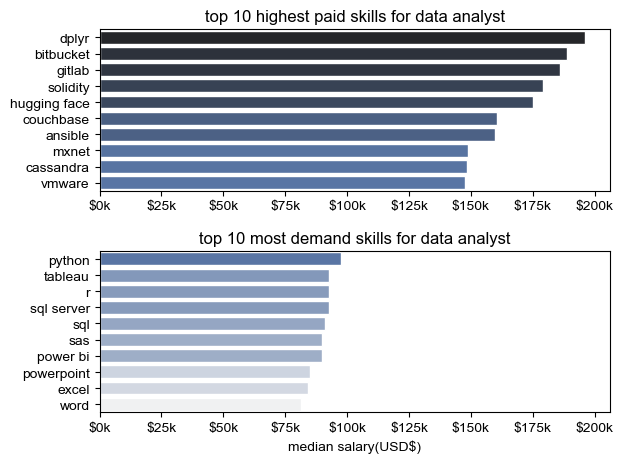

In [12]:
fig, ax = plt.subplots(2, 1)
sns.set_theme(style='ticks')

#df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')
ax[0].legend().remove()
ax[0].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k' )
ax[0].set_title('top 10 highest paid skills for data analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')

#df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:b')
ax[1].legend().remove()
ax[1].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k' )
ax[1].set_title('top 10 most demand skills for data analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('median salary(USD$)')
ax[1].set_xlim(ax[0].get_xlim())

fig.tight_layout()

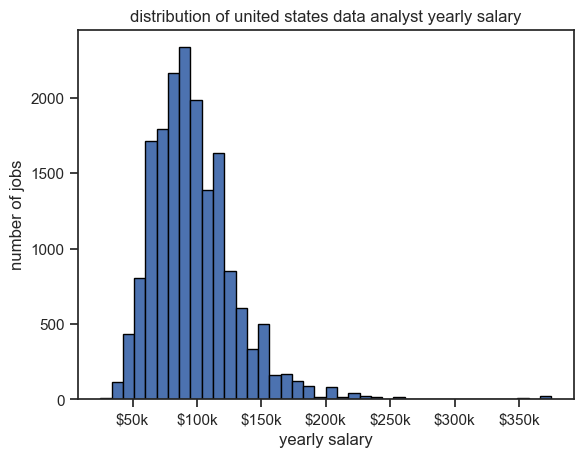

In [14]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')



plt.title('distribution of united states data analyst yearly salary')
plt.xlabel('yearly salary')
plt.ylabel('number of jobs')
ax=plt.gca()
ax.xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k' )
plt.show()

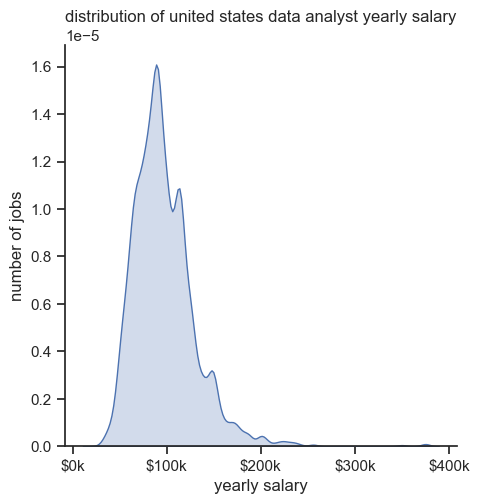

In [16]:
sns.set_theme(style='ticks')
sns.displot(df_DA_US['salary_year_avg'], kind='kde', fill=True)

plt.title('distribution of united states data analyst yearly salary')
plt.xlabel('yearly salary')
plt.ylabel('number of jobs')
ax=plt.gca()
ax.xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k' )
plt.show()

C:\Users\sata\AppData\Local\Temp\ipykernel_3152\4287475164.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


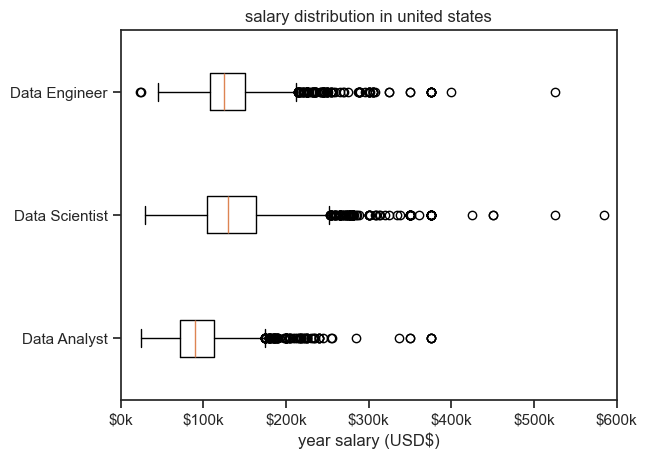

In [17]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short']== job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('salary distribution in united states')
plt.xlabel('year salary (USD$)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.xlim(0, 600000)
plt.show()

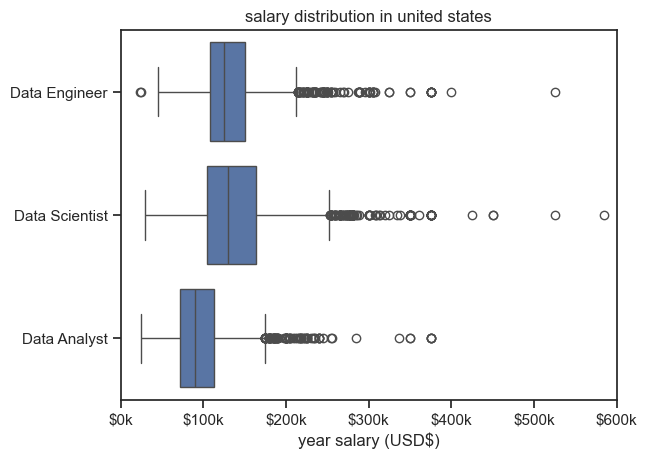

In [20]:
#plt.boxplot(job_list, labels=job_titles, vert=False)
sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short')
plt.title('salary distribution in united states')
plt.xlabel('year salary (USD$)')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.xlim(0, 600000)
plt.show()